# Playground (**OPTIONAL**)
### where we will explore more complex Demographic Scenario with Custom Priors

In this notebook, we will discuss and try to design more realistic prior and model simulation for population scenarios. 

In reality, one population could go through multiple population size epochs with parameters that are difficult to detect (e.g., a random recombination rate). So we will define a prior that samples multiple effective population sizes `Ne_i` together with a random recombination rate. For each effective population size, we place them along pre-defined time windows. Then we simulate data to see how these choices affect the summaries (SFS).

## What we will do
- Define a BoxUniform prior over multiple effective population sizes (across epochs) and a recombination rate randomly sampled from a uniform distribution.
- You can edit epoch times and parameter ranges.
- Simulate tree sequences from sampled parameters.
- Visualize how `Ne` and `change times` shapes the SFS, which becomes our summary statistic for NPE.
- Try to think about how to design the prior and simulation for your own research topic.

**Learning goals:** after this playground you should be able to (i) build a multi-epoch `BoxUniform` prior and the matching `msprime` demography; (ii) explain how epoch spacing (linear/log/exponential) trades off recent vs. ancient resolution; (iii) distinguish demographic signal from coalescent noise by comparing replicates; (iv) reason about how each of these choices would propagate into an NPE posterior (see the take-home exercise at the end).

### Imports and setup
Load msprime, numpy, matplotlib, torch, and BoxUniform for the simulations.


In [1]:
import msprime
import numpy as np
import matplotlib.pyplot as plt
import torch
from sbi.utils import BoxUniform

## Design a more realistic demographic prior
Edit these values to match your use case. 
### Choosing change_times
- Linear spacing (default) gives evenly spaced epochs.
- Exponential spacing (see option below, cf. doi:10.1111/1755-0998.13224) and log spacing cluster the change points nearer the present to resolve recent events more finely.

You can print out the different time intervals to look at the distribution. 

In [2]:
# Demography and sequencing settings
sequence_length = 1e6            # bp
mutation_rate = 1e-8             # per bp per generation
max_time = 5e4                 # maximum time for coalescent events

# Epoch configuration
num_epochs = 5

# Multiple ways to define change times
change_times = np.arange(0, max_time, max_time / num_epochs) 

""" we can also use other spacings for change times. Later in this notebook, we can compare the performance of different spacings.

# Exponential spacing of change times, uncomment to use
change_times =[(np.exp(np.log(1 + 0.1 * 50000) * i / 
                       (num_epochs - 1)) - 1) / 0.1
               for i in range(num_epochs)]

# Logarithmic spacing of change times, uncomment to use
change_times = np.hstack((0, np.logspace(2, np.log10(50000), num_epochs)))
"""

# Prior ranges (Ne and recombination)
ne_range = [100, 1e5]       
recomb_range = [1e-9, 1e-8]  


## Build the prior
We stack `num_epochs` population sizes (`Ne`) plus one recombination rate (`r`) into a single BoxUniform prior.

### Build the BoxUniform prior
Stack epoch-specific `Ne` values and a `recombination rate` into a single prior vector.


In [3]:
param_names = [f"Ne_epoch{i+1}" for i in range(num_epochs)] + ["recomb"]
low = torch.tensor([ne_range[0]] * num_epochs + [recomb_range[0]])
high = torch.tensor([ne_range[1]] * num_epochs + [recomb_range[1]])

prior = BoxUniform(low=low, high=high)

## Simulator
Takes a parameter draw `theta` (`Ne` + `r`), builds the demography with size changes at `change_times`, runs ancestry and mutation simulation, and returns the folded SFS.

### Simulator functions
Simulate demography with epoch-specific Ne and recombination, returning folded SFS and tree sequences.

The simulator takes an optional `seed`: pass an integer for a reproducible run, or leave it as `None` (the default) to get a fresh coalescent replicate on every call. **A single replicate mixes demographic signal with coalescent noise**: the scenario comparison below uses this to check which SFS differences are real.

In [ ]:
def simulator(theta, sequence_length, mutation_rate, change_times, seed=None):
    s_stats = []
    TSs = []
    for pop in theta.tolist():
        ts = simulate_population(pop,
                                 sequence_length=sequence_length,
                                 samples=10,
                                 mutation_rate=mutation_rate,
                                 change_times=change_times,
                                 seed=seed)
        s = ts.allele_frequency_spectrum(polarised=False) # returns folded SFS. Set polarised=True to use unfolded SFS
        s_stats.append(s)
        TSs.append(ts)
    return torch.tensor(s_stats, dtype=torch.float32), TSs

def simulate_population(pop, sequence_length, samples, mutation_rate, change_times, seed=None):
    Ne = pop[:-1]
    r = pop[-1]
    # Define demography
    demography = msprime.Demography()
    demography.add_population(initial_size=Ne[0])

    for t, ne in zip(change_times[1:], Ne[1:]):
        demography.add_population_parameters_change(time=t, initial_size=ne)

    # Simulate ancestry and mutations
    # seed=None -> a new random replicate each call; fix the seed for reproducibility
    ts_anc = msprime.sim_ancestry(samples=samples,
                                recombination_rate=r,
                                sequence_length=sequence_length,
                                demography=demography, random_seed=seed)
    ts = msprime.sim_mutations(ts_anc, rate=mutation_rate, random_seed=seed)

    return ts

## Inspect one draw
Sample parameters, run a simulation, and look at the folded SFS counts.

### Sample one draw and simulate
Draw parameters from the prior and run the simulator once.


In [ ]:
theta_sample = prior.sample((1,))
sfs, ts = simulator(theta_sample, sequence_length, mutation_rate, change_times, seed=42)  # fixed seed: reproducible draw

### Inspect the first TreeSequence object


In [6]:
ts[0]

### Report tree and site counts


In [7]:
print("Trees:", ts[0].num_trees, "sites:", ts[0].num_sites)

Trees: 1927 sites: 8506


### Plot folded SFS for the sampled demography


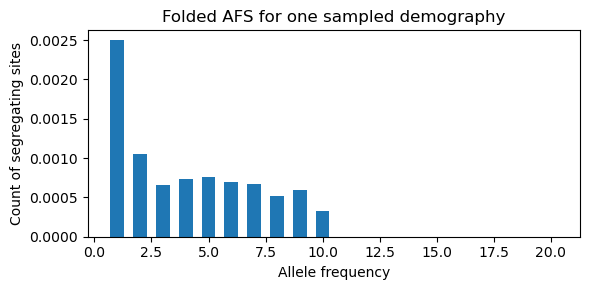

In [8]:
freqs = np.arange(1, len(sfs.squeeze()))
plt.figure(figsize=(6, 3))
plt.bar(freqs, sfs.squeeze()[1:], width=0.6)
plt.xlabel('Site frequency')
plt.ylabel('Count of segregating sites')
plt.title('Folded SFS for one sampled demography')
plt.tight_layout()
plt.show()

## Six demographic scenarios and their SFS
Below we compare six hand-crafted `Ne` trajectories (`Medium, Large, Decline, Expansion, Bottleneck, Zigzag`; cf. doi:10.1111/1755-0998.13224), each defined over 21 epochs, with a fixed recombination rate `1e-8`. 

Each trajectory is a sequence of population sizes across time windows. We simulate each scenario and plot its **normalized folded SFS** (counts divided by total segregating sites) to show how demographic history reshapes the site frequency distribution in a single view.

**Note on coalescent noise:** each curve below is, by default, a single coalescent replicate (`n_reps = 1`), so some visible differences are randomness, not demography. Re-run a plot cell and watch which features move. Set `n_reps = 3` (or more) to average replicates — differences that survive averaging are demographic signal. (Averaging multiplies runtime accordingly.)

### Define six demographic trajectories
Log10 Ne profiles for Medium, Large, Decline, Expansion, Bottleneck, Zigzag; convert to Ne.


In [9]:
# Population sizes are defined on a log10 scale

# Reminder: times are reversed in msprime, so time 0 is present and time max_time is the past!

scenarios = {'Medium': [3.7, 3.7, 3.7, 3.7, 3.7, 3.7, 3.7, 3.7, 3.7, 3.7, 3.7, 3.7, 3.7, 3.7, 3.7, 3.7, 3.7, 3.7, 3.7, 3.7, 3.7],   
             'Large': 4.7 * np.ones(shape=21, dtype='float'), 
             'Decline': [2.5, 2.5, 3, 3, 3, 3, 3.2, 3.4, 3.6, 3.8, 4, 4.2, 4.6, 4.6, 4.6, 4.6, 4.6, 4.6, 4.6, 4.6, 4.6], 
             'Expansion': [4.7, 4.7, 4.7, 4.6, 4.6, 4.5, 4.4, 4.3, 4, 3.7, 3.4, 3.4, 3.4, 3.4, 3.4, 3.4, 3.4, 3.4, 3.4, 3.4, 3.4], 
             'Bottleneck': [4.8, 4.8, 4.8, 4.8, 4.8, 4.8, 4.8, 4.8, 4.8, 4.5, 4.15, 3.8, 4.3, 4.8, 4.55, 4.3, 4.05, 3.8, 3.8, 3.8, 3.8], 
             'Zigzag': [4.8, 4.8, 4.8, 4.5, 4.15, 3.8, 4.15, 4.5, 4.8, 4.5, 4.15, 3.8, 4.3, 4.8, 4.55, 4.3, 4.05, 3.8, 3.8, 3.8, 3.8]}
scenarios = {k:10**np.array(scenarios[k]) for k in scenarios.keys()}

### Plot normalized folded SFS (linear change times)
Compare scenarios with evenly spaced change times; SFS normalized by total segregating sites.


In [ ]:
n_reps = 1  # increase (e.g. 3) to average out coalescent noise; runtime scales linearly

plt.figure(figsize=(8, 5))
for idx, sce in enumerate(scenarios):
    Ne_sce = scenarios[sce]
    pop_params = list(Ne_sce) + [1e-8]
    sfs_reps = []
    for rep in range(n_reps):
        sfs_sce, ts_sce = simulator(torch.tensor([pop_params], dtype=torch.float32),
                                   sequence_length, mutation_rate, np.arange(0, 130000, 130000 / 21))
        sfs_sce = sfs_sce / sfs_sce.sum()  # normalize each replicate
        sfs_reps.append(sfs_sce.squeeze())
    sfs_mean = torch.stack(sfs_reps).mean(dim=0)
    freqs = np.arange(1, len(sfs_mean))

    bar_width = 3 / len(Ne_sce)
    offset = (idx - (len(Ne_sce)-1)/2) * bar_width
    plt.bar(freqs + offset, sfs_mean[1:].numpy(), width=bar_width, label=f'{sce}')

plt.xlabel('Site frequency')
plt.ylabel('Normalized segregating sites')
plt.title('Folded SFS across scenarios (linear change times)')
plt.legend(title='Scenarios', fontsize='small', loc='upper right')
plt.tight_layout()
plt.show() 

### Plot normalized folded SFS (log-spaced change times)
Compare scenarios with log-spaced change times; SFS normalized.


In [ ]:
n_reps = 1  # increase (e.g. 3) to average out coalescent noise; runtime scales linearly

plt.figure(figsize=(8, 5))
for idx, sce in enumerate(scenarios):
    Ne_sce = scenarios[sce]
    pop_params = list(Ne_sce) + [1e-8]
    sfs_reps = []
    for rep in range(n_reps):
        sfs_sce, ts_sce = simulator(torch.tensor([pop_params], dtype=torch.float32),
                                   sequence_length, mutation_rate, np.hstack((0, np.logspace(2, np.log10(130000), 21))))
        sfs_sce = sfs_sce / sfs_sce.sum()  # normalize each replicate
        sfs_reps.append(sfs_sce.squeeze())
    sfs_mean = torch.stack(sfs_reps).mean(dim=0)
    freqs = np.arange(1, len(sfs_mean))

    bar_width = 3 / len(Ne_sce)
    offset = (idx - (len(Ne_sce)-1)/2) * bar_width
    plt.bar(freqs + offset, sfs_mean[1:].numpy(), width=bar_width, label=f'{sce}')

plt.xlabel('Site frequency')
plt.ylabel('Normalized segregating sites')
plt.title('Folded SFS across scenarios (log-spaced change times)')
plt.legend(title='Scenarios', fontsize='small', loc='upper right')
plt.tight_layout()
plt.show() 

### Plot normalized folded SFS (exponential change times)
Compare scenarios with exponentially spaced change times; SFS normalized.


In [ ]:
n_reps = 1  # increase (e.g. 3) to average out coalescent noise; runtime scales linearly

plt.figure(figsize=(8, 5))
for idx, sce in enumerate(scenarios):
    Ne_sce = scenarios[sce]
    pop_params = list(Ne_sce) + [1e-8]
    sfs_reps = []
    for rep in range(n_reps):
        sfs_sce, ts_sce = simulator(torch.tensor([pop_params], dtype=torch.float32),
                                   sequence_length, mutation_rate, [(np.exp(np.log(1 + 0.1 * 130000) * i / (21 - 1)) - 1) / 0.1 for i in range(21)])
        sfs_sce = sfs_sce / sfs_sce.sum()  # normalize each replicate
        sfs_reps.append(sfs_sce.squeeze())
    sfs_mean = torch.stack(sfs_reps).mean(dim=0)
    freqs = np.arange(1, len(sfs_mean))

    bar_width = 3 / len(Ne_sce)
    offset = (idx - (len(Ne_sce)-1)/2) * bar_width
    plt.bar(freqs + offset, sfs_mean[1:].numpy(), width=bar_width, label=f'{sce}')

plt.xlabel('Site frequency')
plt.ylabel('Normalized segregating sites')
plt.title('Folded SFS across scenarios (exponential change times)')
plt.legend(title='Scenarios', fontsize='small', loc='upper right')
plt.tight_layout()
plt.show() 

## Why your prior matters
A good prior is not just a formal requirement, it shapes every simulation you pass to NPE. 

We need to consider how to:
- Cover the plausible space: set `Ne` and `recombination` ranges wide enough to include what you truly expect, but not too wide that most simulations are unrealistic noise.
- Resolve time scales: choose change time grids (`linear/log/exponential` and so on) that give better resolution where you care about recent vs. ancient events.
- Match the biological scenario: set `mutation/recombination` ranges and Ne magnitudes that reflect your system (e.g., human vs. microbial vs. plant).
- Balance breadth and density: if the prior is too broad, NPE spends capacity on unlikely regions. If the prior is too narrow, you would likely miss the truth.

When your prior is thoughtfully designed, the simulated SFS summaries become far more informative, and NPE learns a sharper, better-calibrated posterior.

### What would these choices do to an actual NPE posterior?

We do not train NPE in this notebook (it is the optional playground, and training several variants live would eat the session), but each design choice above maps onto a concrete, predictable effect that you can verify as a take-home exercise with the training loop from notebook 3:

- **Prior too narrow (truth excluded):** simulate "observed" data with `Ne = 50,000` but train with a prior capped at 10,000. Expected result: the posterior piles up against the upper prior boundary — a one-sided, boundary-hugging posterior is the classic signature of a prior that excludes the truth.
- **Prior very wide + small simulation budget:** widen the ranges by 10x while keeping `num_simulations` fixed. Expected result: broad, diffuse posteriors — the network spreads its limited training data over a much larger space, so every region is learned poorly.
- **Epoch spacing vs. resolution:** compare linear and log-spaced `change_times` when the event of interest is recent. Expected result: log spacing constrains recent epochs more tightly at the cost of ancient resolution — as the SFS comparisons above already hint.
- **Non-identifiability you cannot fix with priors:** some trajectories above (e.g. `Bottleneck` vs `Zigzag`) may produce near-identical SFS. No prior tweak recovers information the summary statistic does not carry — the fix is a more informative statistic (LD or haplotype-based) or an embedding network over raw genotypes, as in notebook 5.

### Take-home exercise

Pick one bullet above, implement it with the notebook-3 training loop, and check the expected result with a pairplot and SBC. If the SBC rank histograms are U-shaped, the posterior is over-confident; if hump-shaped, under-confident.

#### What if we use a random recombination rate in this example instead of a fixed one? Try to configure it yourself and play around.

**Expected outcome:** the added parameter becomes one more prior dimension and one more inferred axis. With the SFS as the only summary statistic, expect its posterior to stay close to the prior — the expected folded SFS is nearly invariant to the recombination rate, so there is little signal to learn. (That insensitivity is exactly why notebook 5 switches to genotype-matrix features when inferring recombination.)